# 09 — SIM & Cellular Connectivity Analysis

Analyzes the **de-hardwaring ladder** of cellular identity — eSIM → iSIM → SoftSIM — alongside the GSMA specifications (SGP.32 / SGP.41 / SGP.42) and adjacent network evolutions (NTN, 5G-Advanced, 6G), and **compares them against traditional communication methods** (removable SIM, analog PSTN line, wired Ethernet).

Outputs feed the frontend `SIM & Connectivity` page:
- `frontend/data/sim_technologies.json` — tagged catalog (canonical source: `src/research/sim_technologies.py`)
- `frontend/data/sim_comparison.json` — derived comparison vs traditional methods

分析行動身分的**去硬體化階梯**（eSIM → iSIM → SoftSIM），並與**傳統通訊方式**（可插拔 SIM、類比 PSTN 線路、有線乙太網路）比較。

In [1]:
import sys
import json
import os
from pathlib import Path

# Resolve repo root whether run from repo root or notebooks/ dir.
ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.research.sim_technologies import build_sim_catalog

%matplotlib inline
sns.set_theme(style='whitegrid')

PROCESSED = Path('data/processed')
FRONTEND_DATA = Path('frontend/data')
PROCESSED.mkdir(parents=True, exist_ok=True)

## 1. Load the tagged SIM technology catalog
Each entry carries machine-readable `tags` and a bilingual `maturity` label so the frontend can render and filter them consistently.

In [2]:
catalog = build_sim_catalog()
df = pd.DataFrame(catalog)
print(f'Loaded {len(df)} SIM technologies / specifications')
df['tag_str'] = df['tags'].apply(lambda t: ', '.join(t))
display(df[['id', 'name_en', 'maturity', 'footprint_mm2', 'power_en', 'tag_str']])

Loaded 8 SIM technologies / specifications


,id,name_en,maturity,footprint_mm2,power_en,tag_str
0,esim,eSIM (Embedded SIM),mainstream,30.0,Baseline,"esim, euicc, hardware, rsp, consumer, iot"
1,isim,iSIM (Integrated SIM),emerging,1.0,Up to 70% lower than eSIM,"isim, soc, tee, hardware, iot, miniaturization..."
2,softsim,SoftSIM / vSIM (Software / Virtual SIM),frontier,0.0,No SIM hardware draw,"softsim, vsim, software-defined, no-hardware, ..."
3,sgp32,GSMA SGP.32 (IoT eSIM / RSP),standard,NaN,N/A (specification),"spec, gsma, rsp, iot, eim, interoperability"
4,sgp41-42,GSMA SGP.41 / SGP.42 (iSIM),standard,NaN,N/A (specification),"spec, gsma, isim, eim, rsp, architecture"
5,ntn,NTN (Non-Terrestrial Networks / Direct-to-Cell),emerging,NaN,Device-dependent,"ntn, satellite, direct-to-cell, coverage, 3gpp..."
6,5g-advanced,5G-Advanced (5.5G),emerging,NaN,Network-dependent,"5g-advanced, 5.5g, network-slicing, 3gpp, rel1..."
7,6g,6G Connectivity (Future),frontier,NaN,Research target: ultra-low,"6g, future, ai-native, integrated-sensing, res..."


## 2. Define traditional baselines
We anchor the new SIM technologies against the incumbents they aim to replace, scoring each on footprint, a relative power index (removable SIM = 100), a relative SIM-related BOM-cost index, the provisioning model, and whether the operator profile is remotely switchable.

In [3]:
# (footprint_mm2, power_index, bom_index, provisioning, remote_switchable, kind)
BASELINES = [
    {'option': 'Analog PSTN line',  'footprint_mm2': None, 'power_index': None, 'bom_index': 60,
     'provisioning': 'Physical wiring', 'remote_switchable': False, 'kind': 'traditional'},
    {'option': 'Wired Ethernet/IP', 'footprint_mm2': None, 'power_index': None, 'bom_index': 50,
     'provisioning': 'Physical wiring / DHCP', 'remote_switchable': False, 'kind': 'traditional'},
    {'option': 'Removable SIM (2FF/3FF/4FF)', 'footprint_mm2': 120, 'power_index': 100, 'bom_index': 100,
     'provisioning': 'Manual card swap', 'remote_switchable': False, 'kind': 'traditional'},
]

# Map the catalog onto the same comparison axes.
POWER_INDEX = {'esim': 100, 'isim': 30, 'softsim': 5}          # iSIM ~70% lower; SoftSIM no SIM-HW draw
BOM_INDEX   = {'esim': 70,  'isim': 25, 'softsim': 0}           # relative SIM-related BOM cost
PROVISIONING = {
    'esim': 'OTA RSP (SGP.22)', 'isim': 'OTA RSP via eIM (SGP.42)',
    'softsim': 'Software / cloud download', 'sgp32': 'eIM RSP (SMS-free)',
    'sgp41-42': 'eIM RSP (SMS-free)', 'ntn': 'Inherited (satellite handover)',
    '5g-advanced': 'Slice-aware (SIM-bound)', '6g': 'Research',
}

rows = list(BASELINES)
for c in catalog:
    rows.append({
        'option': c['name_en'],
        'footprint_mm2': c['footprint_mm2'],
        'power_index': POWER_INDEX.get(c['id']),
        'bom_index': BOM_INDEX.get(c['id']),
        'provisioning': PROVISIONING.get(c['id'], 'N/A'),
        'remote_switchable': c['id'] not in ('6g',),
        'kind': 'new',
    })
comp = pd.DataFrame(rows)
display(comp)

,option,footprint_mm2,power_index,bom_index,provisioning,remote_switchable,kind
0,Analog PSTN line,NaN,NaN,60.0,Physical wiring,False,traditional
1,Wired Ethernet/IP,NaN,NaN,50.0,Physical wiring / DHCP,False,traditional
2,Removable SIM (2FF/3FF/4FF),120.0,100.0,100.0,Manual card swap,False,traditional
3,eSIM (Embedded SIM),30.0,100.0,70.0,OTA RSP (SGP.22),True,new
4,iSIM (Integrated SIM),1.0,30.0,25.0,OTA RSP via eIM (SGP.42),True,new
5,SoftSIM / vSIM (Software / Virtual SIM),0.0,5.0,0.0,Software / cloud download,True,new
6,GSMA SGP.32 (IoT eSIM / RSP),NaN,NaN,NaN,eIM RSP (SMS-free),True,new
7,GSMA SGP.41 / SGP.42 (iSIM),NaN,NaN,NaN,eIM RSP (SMS-free),True,new
8,NTN (Non-Terrestrial Networks / Direct-to-Cell),NaN,NaN,NaN,Inherited (satellite handover),True,new
9,5G-Advanced (5.5G),NaN,NaN,NaN,Slice-aware (SIM-bound),True,new


## 3. The de-hardwaring trend — footprint & power collapse
From removable SIM (~120 mm², 100% power) down to SoftSIM (0 mm², ~5% SIM-related power draw).

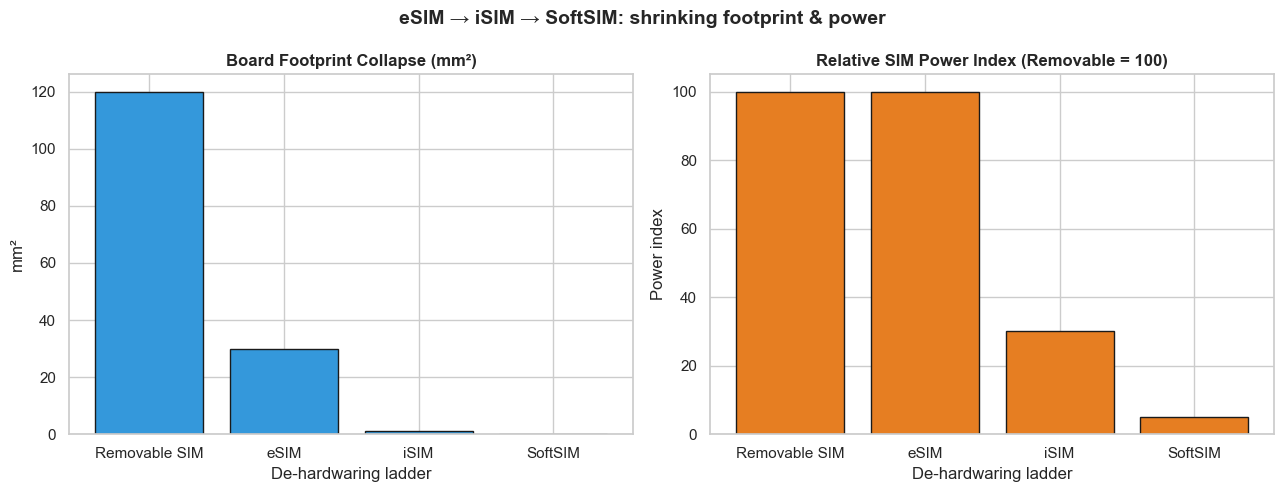

In [4]:
ladder = comp[comp['option'].str.contains('Removable SIM|eSIM|iSIM|SoftSIM', regex=True)].copy()
ladder = ladder.dropna(subset=['footprint_mm2', 'power_index'])
order = ['Removable SIM (2FF/3FF/4FF)', 'eSIM (Embedded SIM)',
         'iSIM (Integrated SIM)', 'SoftSIM / vSIM (Software / Virtual SIM)']
ladder['option'] = pd.Categorical(ladder['option'], categories=order, ordered=True)
ladder = ladder.sort_values('option')
labels = ['Removable SIM', 'eSIM', 'iSIM', 'SoftSIM']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(labels, ladder['footprint_mm2'], color='#3498db', edgecolor='k')
axes[0].set_title('Board Footprint Collapse (mm\u00b2)', fontweight='bold')
axes[0].set_ylabel('mm\u00b2')
axes[1].bar(labels, ladder['power_index'], color='#e67e22', edgecolor='k')
axes[1].set_title('Relative SIM Power Index (Removable = 100)', fontweight='bold')
axes[1].set_ylabel('Power index')
for ax in axes:
    ax.set_xlabel('De-hardwaring ladder')
fig.suptitle('eSIM \u2192 iSIM \u2192 SoftSIM: shrinking footprint & power', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(PROCESSED / 'sim_dehardwaring.png', dpi=150)
plt.show()

## 4. Maturity distribution across catalog

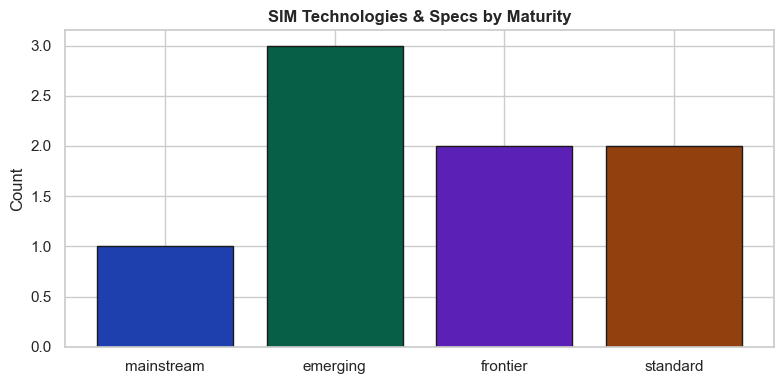

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
mat = df['maturity'].value_counts().reindex(['mainstream', 'emerging', 'frontier', 'standard']).dropna()
colors = {'mainstream': '#1e40af', 'emerging': '#065f46', 'frontier': '#5b21b6', 'standard': '#92400e'}
ax.bar(mat.index, mat.values, color=[colors[m] for m in mat.index], edgecolor='k')
ax.set_title('SIM Technologies & Specs by Maturity', fontweight='bold')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(PROCESSED / 'sim_maturity.png', dpi=150)
plt.show()

## 5. Traditional vs SIM-evolution comparison matrix
Provisioning model and remote switchability — the operational gap between incumbents and software-defined identity.

In [6]:
matrix = comp[['option', 'kind', 'footprint_mm2', 'power_index', 'bom_index',
               'provisioning', 'remote_switchable']].copy()
display(matrix.style.set_properties(**{'text-align': 'left'}))

,option,kind,footprint_mm2,power_index,bom_index,provisioning,remote_switchable
0,Analog PSTN line,traditional,nan,nan,60.000000,Physical wiring,False
1,Wired Ethernet/IP,traditional,nan,nan,50.000000,Physical wiring / DHCP,False
2,Removable SIM (2FF/3FF/4FF),traditional,120.000000,100.000000,100.000000,Manual card swap,False
3,eSIM (Embedded SIM),new,30.000000,100.000000,70.000000,OTA RSP (SGP.22),True
4,iSIM (Integrated SIM),new,1.000000,30.000000,25.000000,OTA RSP via eIM (SGP.42),True
5,SoftSIM / vSIM (Software / Virtual SIM),new,0.000000,5.000000,0.000000,Software / cloud download,True
6,GSMA SGP.32 (IoT eSIM / RSP),new,nan,nan,nan,eIM RSP (SMS-free),True
7,GSMA SGP.41 / SGP.42 (iSIM),new,nan,nan,nan,eIM RSP (SMS-free),True
8,NTN (Non-Terrestrial Networks / Direct-to-Cell),new,nan,nan,nan,Inherited (satellite handover),True
9,5G-Advanced (5.5G),new,nan,nan,nan,Slice-aware (SIM-bound),True


## 6. Export derived data for the frontend
`sim_comparison.json` is consumed by the `SIM & Connectivity` page to render the traditional-vs-new comparison. The tagged catalog itself is written by `scripts/generate_research_outputs.py` from the same canonical module.

In [7]:
comp_records = json.loads(comp.where(pd.notnull(comp), None).to_json(orient='records'))
payload = {
    'baseline_note_en': 'Power index is relative to a removable SIM (=100). BOM index is relative SIM-related bill-of-materials cost.',
    'baseline_note_zh': '功耗指數以可插拔 SIM 為基準（=100）。BOM 指數為 SIM 相關物料成本的相對值。',
    'rows': comp_records,
}
out = FRONTEND_DATA / 'sim_comparison.json'
out.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + '\n')
comp.to_csv(PROCESSED / 'sim_comparison.csv', index=False)
print(f'Wrote {out} ({len(comp_records)} rows) and data/processed/sim_comparison.csv')

Wrote frontend/data/sim_comparison.json (11 rows) and data/processed/sim_comparison.csv


## 7. Findings

**EN.** Cellular identity is de-hardwaring fast: eSIM removed the card slot, **iSIM** folds the SIM into the SoC (<1 mm², up to 70% less power, TEE-backed), and **SoftSIM** removes the hardware entirely (zero SIM BOM, cloud-managed). The unlock is the **GSMA SGP.32/41/42** specs, which replace SMS-based provisioning with SMS-free eIM Remote SIM Provisioning — the key to fleet-scale operator switching. Compared with traditional methods, the new stack trades physical wiring / manual card swaps for **remote, software-defined provisioning**, and adds **NTN** (satellite reachability for off-grid PBX sites) and **5G-Advanced** network slicing (per-tenant voice QoS SLAs). For SIM-bearer PBX / UCaaS / IoT voice endpoints this means smaller, lower-power, remotely re-homeable devices and a non-PSTN command path for resilience.

**繁中.** 行動身分正快速去硬體化：eSIM 取消卡槽，**iSIM** 將 SIM 收進 SoC（<1 mm²、最高省 70% 功耗、TEE 保護），**SoftSIM** 則完全移除硬體（零 SIM BOM、雲端管理）。關鍵推力是 **GSMA SGP.32/41/42**，以免 SMS 的 eIM 遠端配置取代舊式 SMS 流程，成為機隊規模切換營運商的鑰匙。相較傳統方式，新堆疊以**遠端、軟體定義的配置**取代實體佈線與手動換卡，並加入 **NTN**（離網 PBX 站點的衛星可達性）與 **5G-Advanced** 網路切片（租戶級語音 QoS SLA）。對 SIM 承載的 PBX / UCaaS / IoT 語音端點而言，代表更小、更省電、可遠端重新歸屬的裝置，以及具韌性的非 PSTN 控制路徑。